# Lab 4: Model-Based Offline Optimization

In this lab, we explore **Model-Based Offline Optimization (MBO)**, a method to optimize black-box functions using only a pre-collected dataset, without additional function evaluations. We'll use two functions from the **Black-Box Optimization Benchmarking (BBOB)** suite:
- **f1** [Sphere Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=5): A simple, unimodal function with a global minimum at (0, 0).
- **f22** [Gallagher's Gaussian 21-hi Peaks Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=110): A complex, multimodal function with many local optima.

Visualizations of these problems are available [here](https://coco-platform.org/testsuites/bbob/viz.html?col=3&dim=2&fun=1&ins=1&typ=all).

### Objectives
1. **Dataset:** Use pre-collected datasets (100k samples each) for f1 and f22, generated via **Latin Hypercube Sampling (LHS)** [learn more about LHS here](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).
2. **Surrogate Model:** Train a Multi-Layer Perceptron (MLP) to approximate these functions.
3. **Visualization:** Compare the MLP's predictions to the true functions using contour and scatter plots.
4. **Optimization:** Implement gradient-based optimization on the MLP to find optimal points.
5. **Experiments:** Investigate how training dataset size and model complexity affect performance.

### Key Concepts
- **Offline Optimization:** No new evaluations of the true function are allowed; we rely solely on the dataset.
- **Surrogate Model:** The MLP acts as a cheap, differentiable proxy for the expensive black-box function.
- **Gradient-Based Optimization:** Use the MLP's gradients to find optimal designs efficiently.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

### 1. Data Preparation

We start by loading and splitting the dataset into training, validation, and test sets.

In [2]:
def prepare_dataloaders(
    file_path: str,
    batch_size: int = 256,
    train_perc: float = 0.6,
    val_perc: float = 0.2,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Prepare train, validation and test dataloaders.

    Args:
        file_path: Path to CSV data file
        batch_size: Batch size for dataloaders
        train_perc: Percentage of data for training
        val_perc: Percentage of data for validation
    """
    # Load data
    data_df = pd.read_csv(file_path)
    X = torch.tensor(data_df[["x1", "x2"]].values, dtype=torch.float32)
    y = torch.tensor(data_df["y"].values.reshape(-1, 1), dtype=torch.float32)

    # Split data
    num_samples = len(X)
    indices = np.random.permutation(num_samples)
    train_size = int(train_perc * num_samples)
    val_size = int(val_perc * num_samples)

    # Create datasets
    train_dataset = TensorDataset(X[indices[:train_size]], y[indices[:train_size]])
    val_dataset = TensorDataset(
        X[indices[train_size : train_size + val_size]],
        y[indices[train_size : train_size + val_size]],
    )
    test_dataset = TensorDataset(
        X[indices[train_size + val_size :]], y[indices[train_size + val_size :]]
    )

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

    return train_dataloader, val_dataloader, test_dataloader

# Example usage (replace with your file path)
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.3, val_perc=0.4
)

### 2. Define the MLP Model

The MLP will serve as our surrogate model to approximate the black-box function.

In [3]:
class MLP(nn.Module):
    def __init__(
        self, input_dim: int = 2, hidden_dim: int = 256, n_layers: int = 3
    ) -> None:
        """
        Multi-Layer Perceptron (MLP) for function approximation.

        Args:
            input_dim (int): Number of input features (e.g., 2 for x1, x2).
            hidden_dim (int): Number of neurons in each hidden layer.
            n_layers (int): Total number of layers (input + hidden + output).
        """
        super(MLP, self).__init__()

        layers = []
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer -> 1 output neuron (regression, single-objective problem)
        layers.append(nn.Linear(hidden_dim, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

### 3. Training the Model

We train the MLP using the Adam optimizer and Mean Squared Error (MSE) loss.

In [4]:
model = MLP().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss = train_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    val_loss = val_loss / len(val_dataloader.dataset)
    val_losses.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
        )

model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss = test_loss / len(test_dataloader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 10/100, Train Loss: 607.2869, Val Loss: 552.3045
Epoch 20/100, Train Loss: 398.3908, Val Loss: 395.2677
Epoch 30/100, Train Loss: 328.3214, Val Loss: 325.9102
Epoch 40/100, Train Loss: 269.8174, Val Loss: 267.0457
Epoch 50/100, Train Loss: 207.5420, Val Loss: 213.0194
Epoch 60/100, Train Loss: 176.8596, Val Loss: 173.3267
Epoch 70/100, Train Loss: 158.5056, Val Loss: 166.8098
Epoch 80/100, Train Loss: 144.7397, Val Loss: 149.3690
Epoch 90/100, Train Loss: 134.7696, Val Loss: 136.8757
Epoch 100/100, Train Loss: 127.3193, Val Loss: 128.7323
Test Loss: 126.0709


### 4. Visualization

Let's visualize how well the MLP approximates the true function.

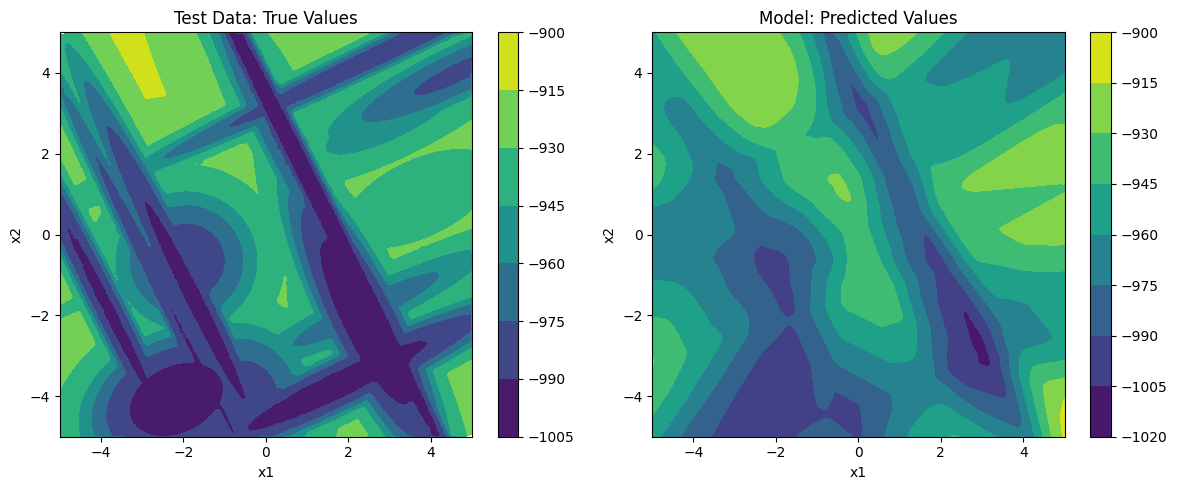

In [5]:
def plot_contour_comparison(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()
    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        predictions = model(grid_tensor).cpu().numpy().flatten()

    Z_pred = predictions.reshape(X1.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    true_contour = ax1.tricontourf(
        test_inputs[:, 0], test_inputs[:, 1], test_targets.reshape(-1)
    )
    ax1.set_title("Test Data: True Values")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    plt.colorbar(true_contour, ax=ax1)

    pred_contour = ax2.contourf(X1, X2, Z_pred)
    ax2.set_title("Model: Predicted Values")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    plt.colorbar(pred_contour, ax=ax2)

    plt.tight_layout()
    plt.show()

plot_contour_comparison(model, test_dataloader, device)

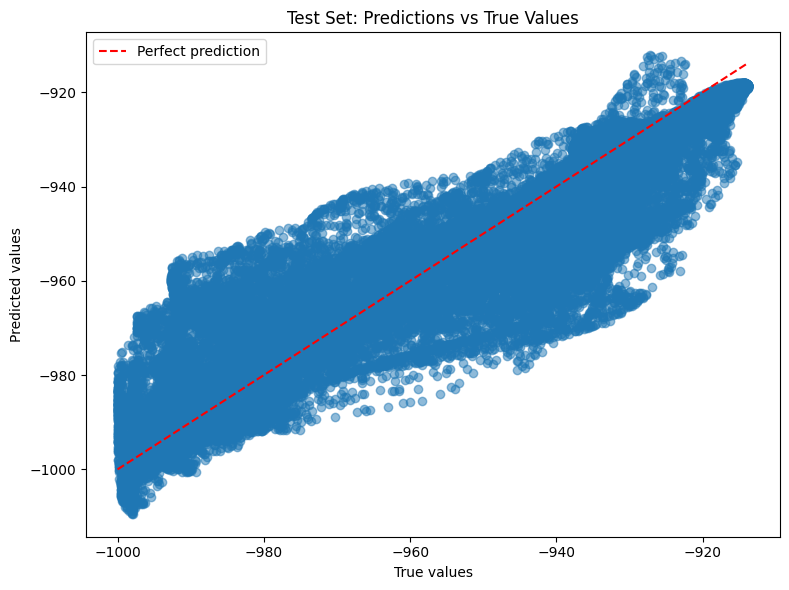

In [6]:
def plot_prediction_scatter(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_targets_list = []
    test_preds_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            outputs = model(inputs)

        test_targets_list.append(targets.cpu().numpy())
        test_preds_list.append(outputs.cpu().numpy())

    test_targets = np.concatenate(test_targets_list)
    test_preds = np.concatenate(test_preds_list).flatten()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(test_targets, test_preds, alpha=0.5)
    ax.plot(
        [test_targets.min(), test_targets.max()],
        [test_targets.min(), test_targets.max()],
        "r--",
        label="Perfect prediction",
    )
    ax.set_xlabel("True values")
    ax.set_ylabel("Predicted values")
    ax.set_title("Test Set: Predictions vs True Values")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_prediction_scatter(model, test_dataloader, device)

### 5. Gradient-Based Optimization

Now, we optimize the trained MLP to find the input that minimizes its output (our surrogate's prediction).

In [9]:
def optimize_model(
    model: nn.Module, num_steps: int = 1000
) -> tuple[torch.Tensor, float]:
    """
    Perform gradient-based optimization on the MLP.

    Args:
        model (nn.Module): Trained MLP model.
        num_steps (int): Number of optimization steps.

    Returns:
        tuple: (best_x, best_y) - Optimal input and its predicted output.
    """
    model.eval()
    # Select random starting point in [-5, 5]^2
    x = torch.rand(1, 2, device=device) * 10 - 5
    x.requires_grad_(True)
    optimizer = torch.optim.Adam([x], lr=0.001)

    best_x, best_y = float('inf'), float('inf')

    for _ in range(num_steps):
        optimizer.zero_grad()
        # Predict output (our output - result of the model is the function we want to minimize)
        # Compute gradients (gradients of our model)
        # Update x
        # Enforce domain constraints [-5, 5]

        output = model(x)
        loss = output
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            x.clamp_(-5, 5)

        current_y = output.item()
        if current_y < best_y:
            best_y = current_y
            best_x = x.detach().clone()
    #
    return best_x, best_y
#

optimize_model(model)

(tensor([[-1.4809, -0.3472]]), -984.610107421875)

### Exercise 1: Impact of Dataset Size
- **Task:** Train the MLP with different training set sizes (e.g., 100, 1000, 5000, 10000, 50000).
- **Instructions:**
  1. Modify the `train_perc` parameter in `prepare_dataloaders` to achieve these different dataset sizes (keep the test set size fixed at approximately 30,000 samples).
  2. Train the model for each dataset size and generate corresponding contour plots.
  3. Analyze how the MLP's ability to capture the underlying function structure (particularly the multimodal nature of f22) improves with increasing data volume.
  4. Select and justify a single quantitative metric that effectively captures the model’s predictive quality in this context. Use this metric to evaluate model performance across different training set sizes. Present the results as a plot to visualize how model quality scales with data availability.

In [ ]:
def train_model(model: nn.Module, train_dataloader: DataLoader, val_dataloader: DataLoader, test_dataloader: DataLoader):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    num_epochs = 100

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for inputs, targets in train_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)

        train_loss = train_loss / len(train_dataloader.dataset)
        train_losses.append(train_loss)
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_dataloader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss = val_loss / len(val_dataloader.dataset)
        val_losses.append(val_loss)
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
            )

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)

    test_loss = test_loss / len(test_dataloader.dataset)
    print(f"Test Loss: {test_loss:.4f}")
#

Epoch 10/100, Train Loss: 908187.0625, Val Loss: 903630.5694
Epoch 20/100, Train Loss: 879631.7500, Val Loss: 874277.9664
Epoch 30/100, Train Loss: 835192.3125, Val Loss: 829077.7976
Epoch 40/100, Train Loss: 771528.2500, Val Loss: 764859.7329
Epoch 50/100, Train Loss: 686701.5000, Val Loss: 679974.0468
Epoch 60/100, Train Loss: 582102.8750, Val Loss: 576201.3458
Epoch 70/100, Train Loss: 463551.3125, Val Loss: 459645.4589
Epoch 80/100, Train Loss: 341520.4688, Val Loss: 340928.5809
Epoch 90/100, Train Loss: 230319.2031, Val Loss: 234193.9349
Epoch 100/100, Train Loss: 144613.2188, Val Loss: 153397.3609
Test Loss: 151702.3141


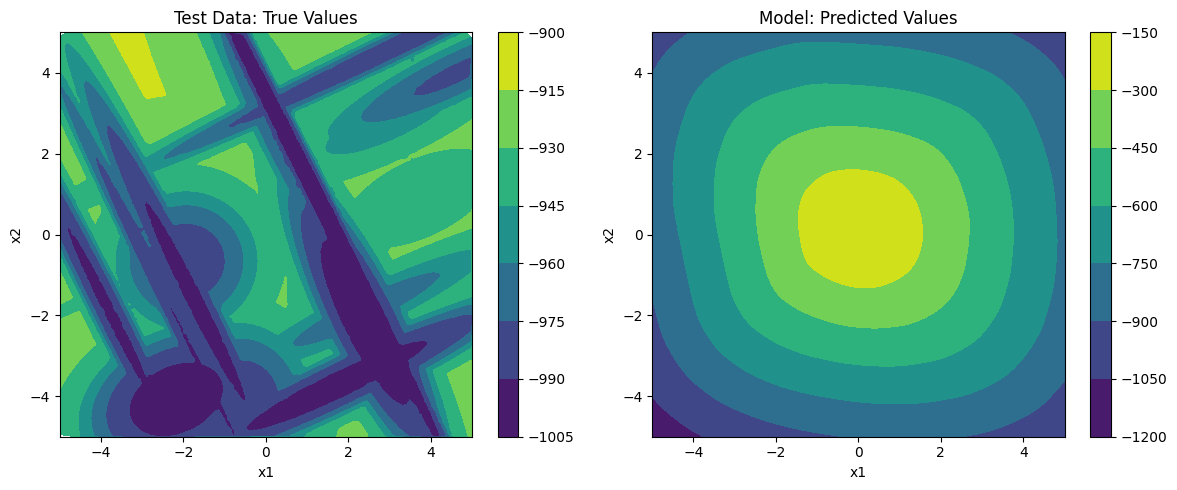

In [12]:
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.001, val_perc=0.699
)
model = MLP()
train_model(model, train_dataloader, val_dataloader, test_dataloader)
plot_contour_comparison(model, test_dataloader, device)

Epoch 10/100, Train Loss: 801784.9380, Val Loss: 784295.8818
Epoch 20/100, Train Loss: 427054.3540, Val Loss: 396480.1505
Epoch 30/100, Train Loss: 107304.2337, Val Loss: 99664.0799
Epoch 40/100, Train Loss: 82369.2226, Val Loss: 81763.9742
Epoch 50/100, Train Loss: 78082.7226, Val Loss: 77878.2826
Epoch 60/100, Train Loss: 74129.9310, Val Loss: 74034.0573
Epoch 70/100, Train Loss: 69998.3305, Val Loss: 69998.3229
Epoch 80/100, Train Loss: 65651.8328, Val Loss: 65691.6288
Epoch 90/100, Train Loss: 61090.6926, Val Loss: 61132.5067
Epoch 100/100, Train Loss: 56331.9952, Val Loss: 56373.9085
Test Loss: 56073.2305


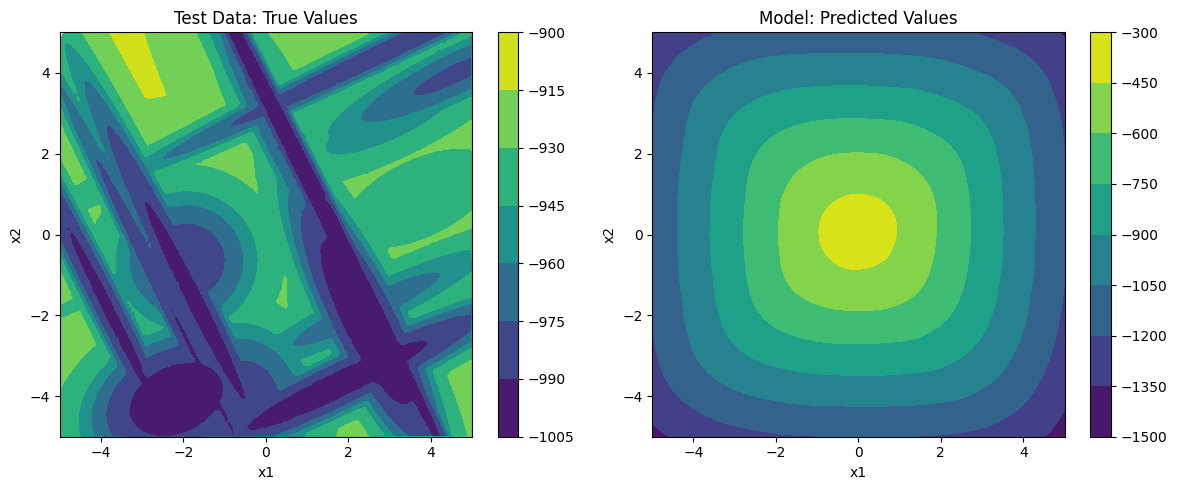

In [13]:
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.01, val_perc=0.69
)
model = MLP()
train_model(model, train_dataloader, val_dataloader, test_dataloader)
plot_contour_comparison(model, test_dataloader, device)

Epoch 10/100, Train Loss: 77298.9049, Val Loss: 77736.9964
Epoch 20/100, Train Loss: 55759.9006, Val Loss: 55465.6076
Epoch 30/100, Train Loss: 30154.2401, Val Loss: 29193.3805
Epoch 40/100, Train Loss: 7972.6210, Val Loss: 7340.4394
Epoch 50/100, Train Loss: 1095.1934, Val Loss: 1018.3370
Epoch 60/100, Train Loss: 491.3447, Val Loss: 491.1572
Epoch 70/100, Train Loss: 421.0372, Val Loss: 423.0463
Epoch 80/100, Train Loss: 381.5404, Val Loss: 381.9711
Epoch 90/100, Train Loss: 352.8743, Val Loss: 354.9953
Epoch 100/100, Train Loss: 333.7359, Val Loss: 334.8068
Test Loss: 330.8913


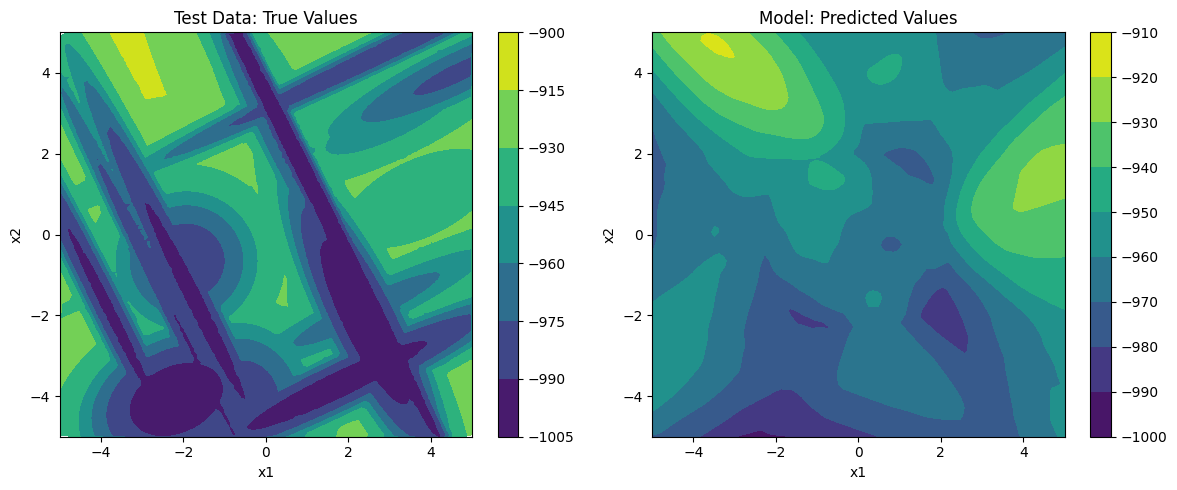

In [14]:
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.05, val_perc=0.65
)
model = MLP()
train_model(model, train_dataloader, val_dataloader, test_dataloader)
plot_contour_comparison(model, test_dataloader, device)

Epoch 10/100, Train Loss: 58479.7772, Val Loss: 55393.8602
Epoch 20/100, Train Loss: 6379.6442, Val Loss: 5143.5163
Epoch 30/100, Train Loss: 480.4264, Val Loss: 468.0052
Epoch 40/100, Train Loss: 355.3318, Val Loss: 357.8646
Epoch 50/100, Train Loss: 311.8206, Val Loss: 315.8812
Epoch 60/100, Train Loss: 285.1332, Val Loss: 287.5671
Epoch 70/100, Train Loss: 263.4529, Val Loss: 267.9807
Epoch 80/100, Train Loss: 246.4742, Val Loss: 249.1292
Epoch 90/100, Train Loss: 232.8540, Val Loss: 232.7721
Epoch 100/100, Train Loss: 220.4527, Val Loss: 221.9509
Test Loss: 221.3021


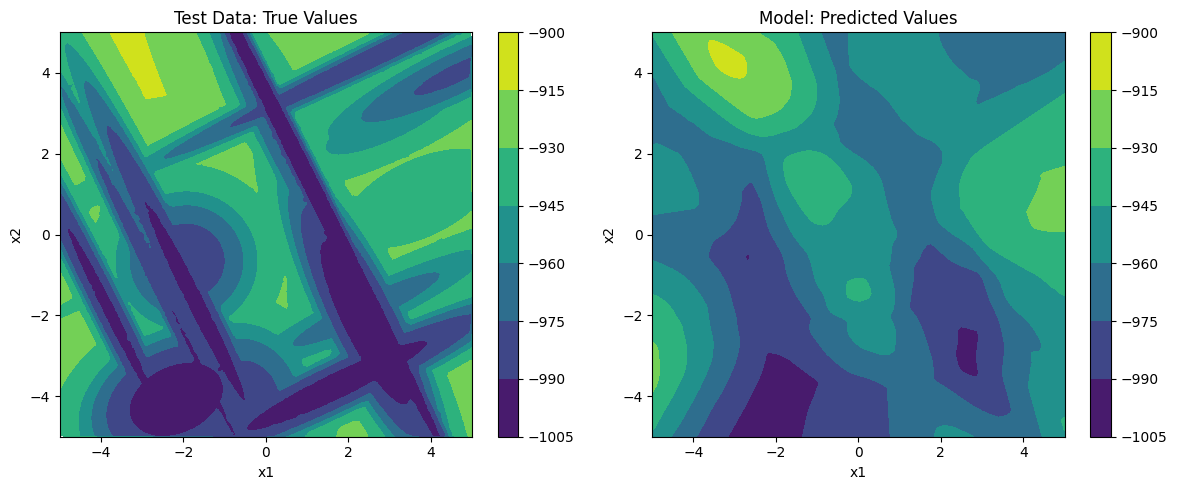

In [15]:
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.1, val_perc=0.6
)
model = MLP()
train_model(model, train_dataloader, val_dataloader, test_dataloader)
plot_contour_comparison(model, test_dataloader, device)

Epoch 10/100, Train Loss: 432.3205, Val Loss: 421.0639
Epoch 20/100, Train Loss: 307.0588, Val Loss: 300.0600
Epoch 30/100, Train Loss: 211.5109, Val Loss: 208.3813
Epoch 40/100, Train Loss: 175.7254, Val Loss: 180.0925
Epoch 50/100, Train Loss: 160.4983, Val Loss: 157.0202
Epoch 60/100, Train Loss: 140.5017, Val Loss: 139.3441
Epoch 70/100, Train Loss: 126.5737, Val Loss: 137.8516
Epoch 80/100, Train Loss: 120.2221, Val Loss: 119.9064
Epoch 90/100, Train Loss: 113.8356, Val Loss: 116.1736
Epoch 100/100, Train Loss: 107.9046, Val Loss: 110.9917
Test Loss: 110.3233


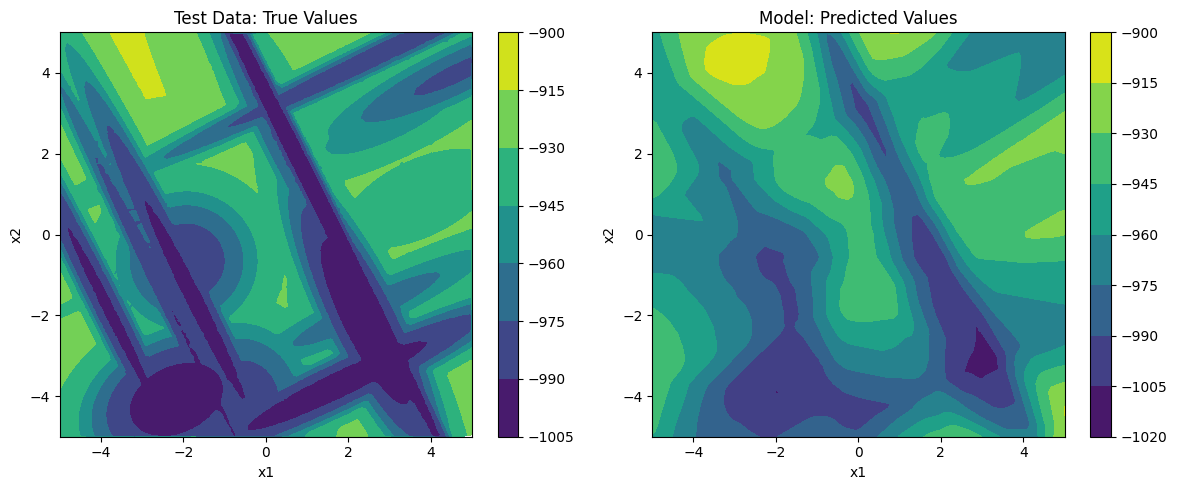

In [16]:
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.5, val_perc=0.2
)
model = MLP()
train_model(model, train_dataloader, val_dataloader, test_dataloader)
plot_contour_comparison(model, test_dataloader, device)

### Exercise 2: Optimization Robustness
- **Task:** Implement the `optimize_model` function to find inputs that minimize the model's output.
- **Instructions:**
  1. Execute the optimization process multiple times (e.g. 10 for each dataset) with different random starting points and record the best surrogate values.
  2. Create a histogram of the best `y` values across all optimization runs to visualize the distribution of results.
  3. Generate a contour plot showing the locations of the solutions found. Analyze the consistency of these solutions.
  4. Use `cocoex` to evaluate the true objective function at the solution points. Compare these values against the surrogate’s predicted values.

### Accessing Original COCO Benchmark Problems

The code below installs and imports the necessary packages to access the original COCO benchmark problems (f1 and f22).
This will allow us to compare our model's predictions with the true functions and evaluate optimization performance.

In [10]:
! pip install coco-experiment cocopp

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/8.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.6 MB 1.4 MB/s eta 0:00:07
     ---------------------------------------- 0.1/8.6 MB 660.6 kB/s eta 0:00:13
      --------------------------------------- 0.1/8.6 MB 1.0 MB/s eta 0:00:09
     - -------------------------------------- 0.3/8.6 MB 1.9 MB/s eta 0:00:05
     --- ------------------------------------ 0.7/8.6 MB 3.9 MB/s eta 0:00:03
     ------- -------------------------------- 1.6/8.6 MB 7.2 MB/s eta 0:00:01
     --------- ------------------------------ 2.0/8.6 MB 8.6 MB/s eta 0:00:01
     --------- ------------------------------ 2.0/8.6 MB 6.8 MB/s eta 0:00:01
     --------- ------------------------------ 2.0/8.6 MB 6.8 MB/s eta 0:00:01
     


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from cocoex import Suite

function_id = 22  # Switch between 1 and 22 to change the function

suite = Suite(
    "bbob",
    "",
    f"function_indices: {function_id}, dimensions: 2 instance_indices: 1",
)
for function in suite:
    print(function.info)
    print("Function value at (0, 0):", function(np.array([0, 0])))

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844
